## Setup

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download and extract dataset

In [2]:
!wget --no-check-certificate https://madm.dfki.de/files/sentinel/EuroSAT.zip -O EuroSAT.zip
!unzip -q -o EuroSAT.zip
!ls

--2026-06-25 22:13:55--  https://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 94280567 (90M) [application/zip]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  89.91M  21.5MB/s    in 5.3s    

2026-06-25 22:14:01 (17.1 MB/s) - ‘EuroSAT.zip’ saved [94280567/94280567]

2750  EuroSAT.zip  sample_data


## Check classes

In [3]:
data_dir = "2750/"
classes = sorted(os.listdir(data_dir))
NUM_CLASSES = len(classes)

print(f"Classes ({NUM_CLASSES}):")
for cls in classes:
    n = len(os.listdir(os.path.join(data_dir, cls)))
    print(f"  {cls}: {n} images")

Classes (10):
  AnnualCrop: 3000 images
  Forest: 3000 images
  HerbaceousVegetation: 3000 images
  Highway: 2500 images
  Industrial: 2500 images
  Pasture: 2000 images
  PermanentCrop: 2500 images
  Residential: 3000 images
  River: 2500 images
  SeaLake: 3000 images


## Sample image per class

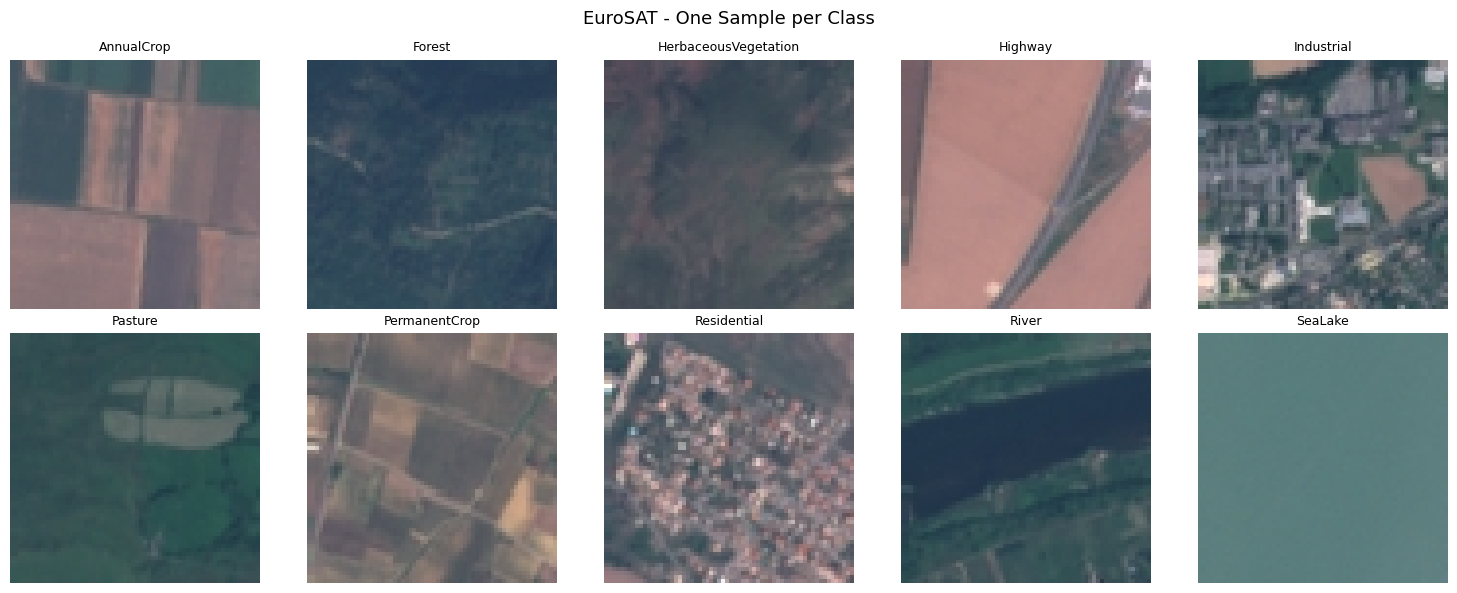

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_dir = os.path.join(data_dir, cls)
    img_path = os.path.join(cls_dir, os.listdir(cls_dir)[0])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

plt.suptitle("EuroSAT - One Sample per Class", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

## Class distribution

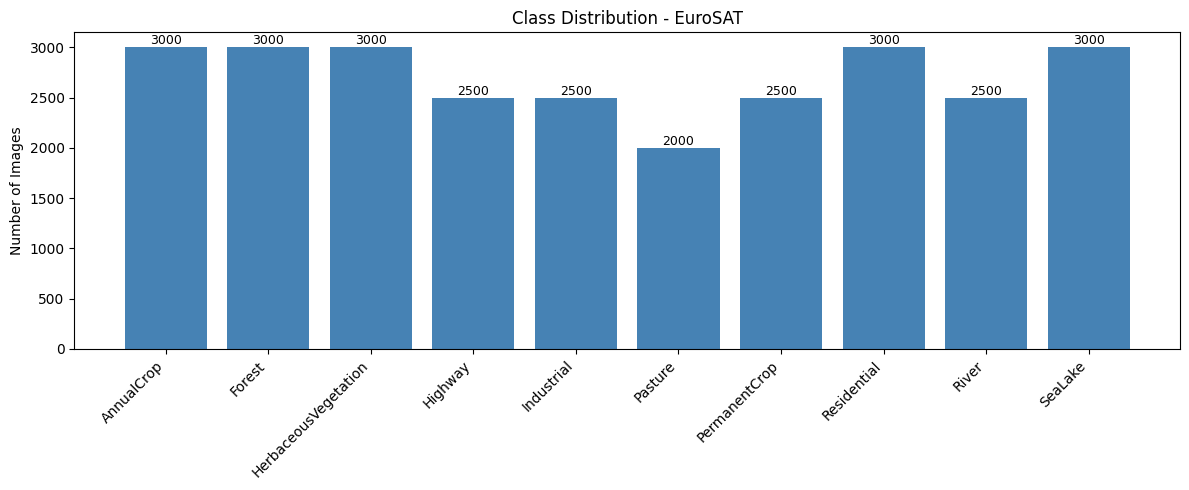

In [5]:
class_counts = [len(os.listdir(os.path.join(data_dir, cls))) for cls in classes]

plt.figure(figsize=(12, 5))
bars = plt.bar(classes, class_counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution - EuroSAT")
plt.ylabel("Number of Images")
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
              str(count), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

## Pixel stats per class

In [6]:
print("Mean pixel values per class:\n")

for cls in classes:
    cls_dir = os.path.join(data_dir, cls)
    imgs = []
    for fname in os.listdir(cls_dir)[:100]:
        img = np.array(Image.open(os.path.join(cls_dir, fname))) / 255.0
        imgs.append(img)
    imgs = np.stack(imgs)
    print(f"{cls:25s} mean: {imgs.mean():.3f}  std: {imgs.std():.3f}")

Mean pixel values per class:

AnnualCrop                mean: 0.474  std: 0.162
Forest                    mean: 0.230  std: 0.069
HerbaceousVegetation      mean: 0.391  std: 0.124
Highway                   mean: 0.390  std: 0.159
Industrial                mean: 0.500  std: 0.193
Pasture                   mean: 0.320  std: 0.090
PermanentCrop             mean: 0.463  std: 0.135
Residential               mean: 0.416  std: 0.131
River                     mean: 0.332  std: 0.113
SeaLake                   mean: 0.278  std: 0.115


## Make train/val/test folders

In [7]:
TRAIN_DIR = "dataset/train"
VAL_DIR   = "dataset/val"
TEST_DIR  = "dataset/test"

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

print("Folders ready.")

Folders ready.


## Split data 80/10/10 and copy files

In [8]:
from sklearn.model_selection import train_test_split

for cls in classes:
    cls_dir = os.path.join(data_dir, cls)
    images = os.listdir(cls_dir)

    train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42)
    val_imgs, test_imgs   = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for fname in train_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(TRAIN_DIR, cls, fname))
    for fname in val_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(VAL_DIR, cls, fname))
    for fname in test_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(TEST_DIR, cls, fname))

print("Split done.")
print(f"Train: ~{len(os.listdir(os.path.join(TRAIN_DIR, classes[0]))) * NUM_CLASSES} images")
print(f"Val:   ~{len(os.listdir(os.path.join(VAL_DIR,   classes[0]))) * NUM_CLASSES} images")
print(f"Test:  ~{len(os.listdir(os.path.join(TEST_DIR,  classes[0]))) * NUM_CLASSES} images")

Split done.
Train: ~24000 images
Val:   ~3000 images
Test:  ~3000 images


## Data generators Uses `preprocess_input` from ResNet50 instead of plain rescale. ResNet50 needs images preprocessed the same way it was trained (ImageNet mean subtraction)

In [9]:
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=60,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', color_mode='rgb', shuffle=True, seed=42
)

val_generator = val_test_gen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', color_mode='rgb', shuffle=False
)

test_generator = val_test_gen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', color_mode='rgb', shuffle=False
)

print("Generators ready.")

Found 21600 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Generators ready.


## Quick check on one batch

In [10]:
print("Class indices:", train_generator.class_indices)
print(f"Train batches: {len(train_generator)}")
print(f"Val batches:   {len(val_generator)}")
print(f"Test batches:  {len(test_generator)}")

images, labels = next(train_generator)
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Pixel range: {images.min():.2f} to {images.max():.2f}")  # will look negative/centered now, that's expected with preprocess_input

Class indices: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
Train batches: 675
Val batches:   85
Test batches:  85
Batch shape: (32, 224, 224, 3)
Labels shape: (32, 10)
Pixel range: -104.68 to 151.06


## Build ResNet50 model

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

def build_resnet50(num_classes=10, fine_tune=False):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = fine_tune

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

model, base_model = build_resnet50(num_classes=NUM_CLASSES, fine_tune=False)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Compile model

In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen    = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
print(f"Trainable: {trainable:,} | Frozen: {frozen:,}")

Trainable: 527,114 | Frozen: 23,587,712


## Callbacks

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath='resnet50_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks ready.")

Callbacks ready.


## Phase 1: train the new head only, backbone frozen\n\nWith correct preprocessing this should already climb past 80-90% val accuracy within a handful of epochs. Early stopping will cut it off once it stops improving, so it won't run the full 15 if it's not needed.

In [14]:
history1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.7473 - loss: 0.7630
Epoch 1: val_accuracy improved from None to 0.90630, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 306s 432ms/step - accuracy: 0.8262 - loss: 0.5195 - val_accuracy: 0.9063 - val_loss: 0.2749 - learning_rate: 0.0010
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8781 - loss: 0.3515
Epoch 2: val_accuracy improved from 0.90630 to 0.91259, saving model to resnet50_best.keras

Epoch 2: finished saving model to resnet50_best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 284s 420ms/step - accuracy: 0.8822 - loss: 0.3436 - val_accuracy: 0.9126 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8921 - loss: 0.3198
Epoch 3: val_accuracy did not improve from 0.91259
675/675 ━━━━━━━━━━━━━━━━━━━━ 277s 410ms/step - accuracy: 0.8905 - loss: 0.3215 - val_accuracy: 0.8926 - 

## Phase 2: unfreeze the backbone and fine-tune at a low learning rate

In [15]:
base_model.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.load_weights('resnet50_best.keras')

history2 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.8110 - loss: 0.6454
Epoch 1: val_accuracy improved from 0.94407 to 0.95259, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 416s 527ms/step - accuracy: 0.8703 - loss: 0.4325 - val_accuracy: 0.9526 - val_loss: 0.1484 - learning_rate: 1.0000e-05
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9220 - loss: 0.2566
Epoch 2: val_accuracy improved from 0.95259 to 0.96519, saving model to resnet50_best.keras

Epoch 2: finished saving model to resnet50_best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 351s 519ms/step - accuracy: 0.9259 - loss: 0.2374 - val_accuracy: 0.9652 - val_loss: 0.1062 - learning_rate: 1.0000e-05
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9386 - loss: 0.1985
Epoch 3: val_accuracy improved from 0.96519 to 0.97111, saving model to resnet50_best.keras

Epoch 3: finished saving model to resnet50_best.ker

## Plot training curves

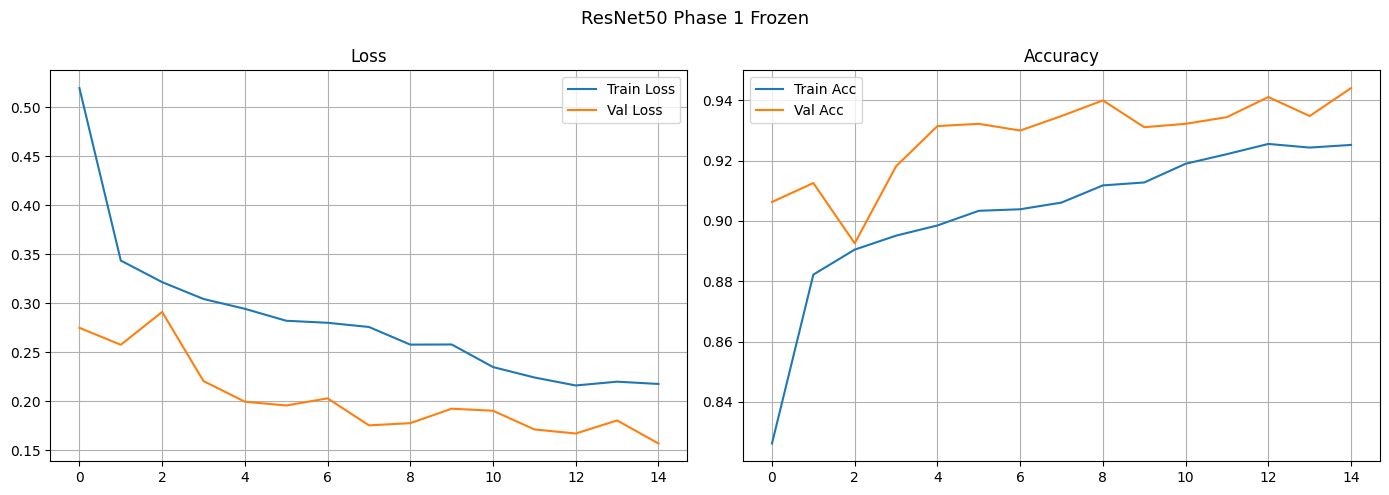

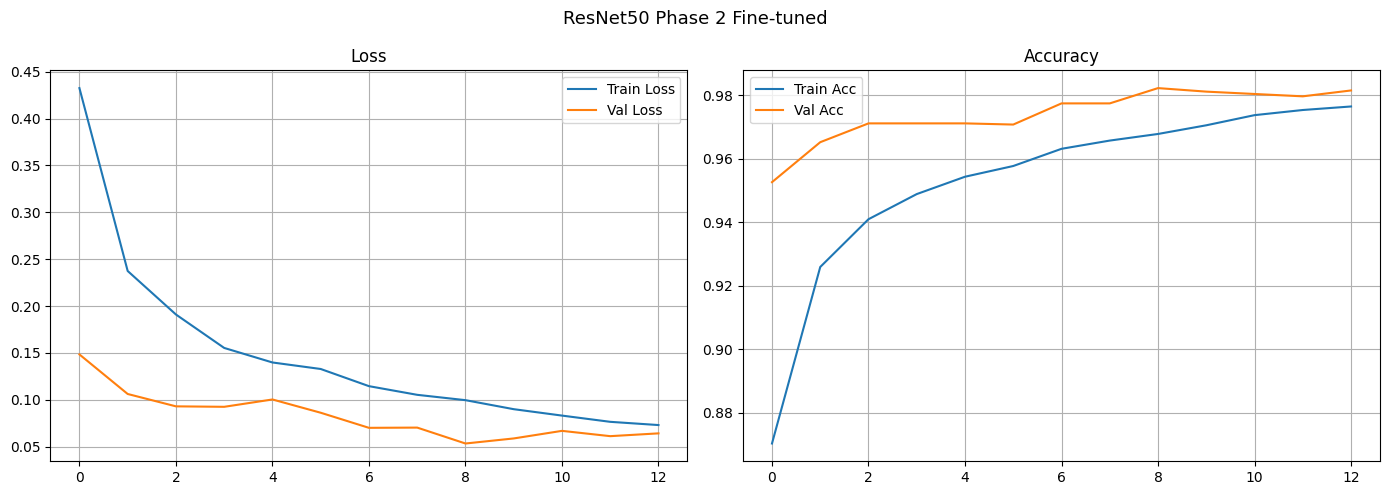

In [16]:
def plot_history(h, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(h.history['loss'], label='Train Loss')
    ax1.plot(h.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

    ax2.plot(h.history['accuracy'], label='Train Acc')
    ax2.plot(h.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png')
    plt.show()

plot_history(history1, "ResNet50 Phase 1 Frozen")
plot_history(history2, "ResNet50 Phase 2 Fine-tuned")

## Evaluate on test set

In [17]:
model.load_weights('resnet50_best.keras')

print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Evaluating on test set...
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.9819 - loss: 0.0627
Test Loss:     0.0627
Test Accuracy: 0.9819


## Confusion matrix and classification report

85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 137ms/step
Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.99      0.97      0.98       300
              Forest       0.99      1.00      0.99       300
HerbaceousVegetation       0.97      0.97      0.97       300
             Highway       0.98      0.98      0.98       250
          Industrial       0.99      0.99      0.99       250
             Pasture       0.99      0.96      0.97       200
       PermanentCrop       0.94      0.97      0.96       250
         Residential       0.99      1.00      1.00       300
               River       0.98      0.98      0.98       250
             SeaLake       1.00      0.99      1.00       300

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



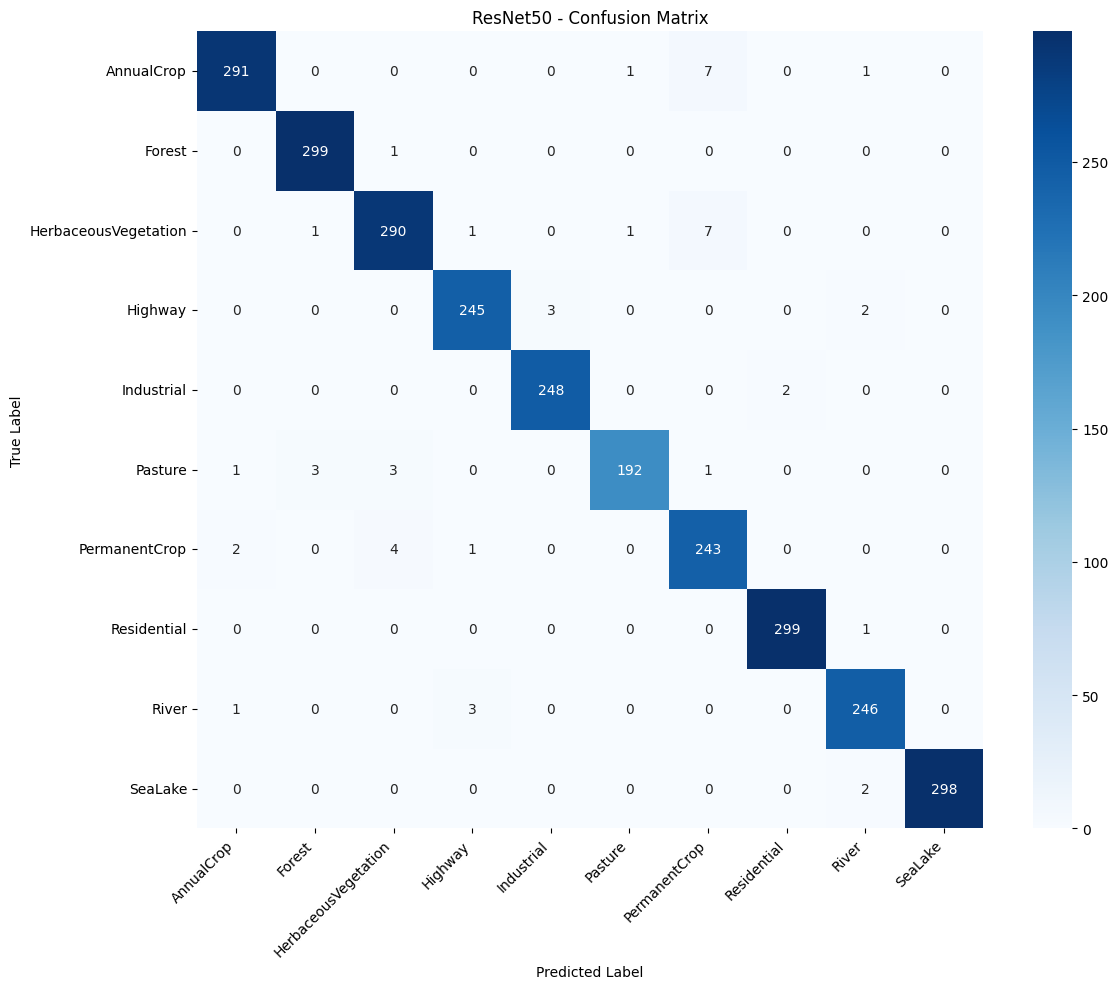

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('ResNet50 - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png')
plt.show()

## Save final model

In [19]:
model.save('resnet50_eurosat_final.keras')
print("Saved: resnet50_eurosat_final.keras")

Saved: resnet50_eurosat_final.keras
